In [1]:
# ============================================================
# PHASE 4 PART 1 — XGBOOST PURCHASE PREDICTOR
# ============================================================
# WHY XGBOOST:
# XGBoost is the most used ML algorithm in industry
# for structured/tabular data. It wins Kaggle competitions,
# it is used in banks, e-commerce, and fintech daily.
# It handles categorical data well, is fast to train,
# and gives feature importance — telling you WHICH input
# matters most for the prediction.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import (classification_report,
                                     confusion_matrix,
                                     accuracy_score)
import xgboost as xgb

sns.set_theme(style="darkgrid")

# Load consumer profiles — this is your training data
consumers_df = pd.read_csv("data/cleaned/chennai_consumers.csv")

print("✅ Libraries loaded")
print(f"   Training data shape: {consumers_df.shape}")
print()
print("Target distribution — what we are predicting:")
print(consumers_df["top_purchase_category"].value_counts())

✅ Libraries loaded
   Training data shape: (5000, 16)

Target distribution — what we are predicting:
top_purchase_category
clothing       1563
electronics     850
food            809
beauty          764
books           512
sports          263
accessories     239
Name: count, dtype: int64


In [2]:
# ============================================================
# STEP 1 — FEATURE PREPARATION AND ENCODING
# ============================================================
# WHY ENCODING:
# XGBoost works with numbers only — not text.
# "instagram" needs to become 0, "tiktok" needs to become 1.
# This conversion is called Label Encoding.
# We save the encoders so later when a user types
# "instagram" in the app we can convert it the same way.
# ============================================================

# Select features and target
# These are the columns the model learns from (features)
# and what it tries to predict (target)
feature_cols = [
    "age_group",
    "primary_platform",
    "top_content_genre",
    "daily_screen_time_hrs",
    "income_bracket",
    "online_shopping_pref",
    "locality"
]
target_col = "top_purchase_category"

# Create a working copy
model_df = consumers_df[feature_cols + [target_col]].copy()

# Store label encoders — we need them later for the app
# When a new user input comes in we use same encoder
# to convert their text to numbers
encoders = {}

categorical_cols = [
    "age_group",
    "primary_platform",
    "top_content_genre",
    "income_bracket",
    "online_shopping_pref",
    "locality"
]

for col in categorical_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    encoders[col] = le
    print(f"   Encoded {col:25s} → {list(le.classes_)}")

# Encode target separately
target_encoder = LabelEncoder()
model_df[target_col] = target_encoder.fit_transform(model_df[target_col])
encoders["target"] = target_encoder

print()
print("Target classes after encoding:")
for i, cls in enumerate(target_encoder.classes_):
    print(f"   {i} → {cls}")
print()
print("✅ All features encoded")
print(f"   Feature matrix shape: {model_df[feature_cols].shape}")

   Encoded age_group                 → ['13-17', '18-24', '25-34', '35-50', '50+']
   Encoded primary_platform          → ['instagram', 'tiktok', 'twitter', 'youtube']
   Encoded top_content_genre         → ['education', 'entertainment', 'fashion', 'finance', 'fitness', 'food', 'technology', 'travel']
   Encoded income_bracket            → ['high', 'low', 'lower-middle', 'middle', 'upper-middle']
   Encoded online_shopping_pref      → ['high', 'low', 'medium']
   Encoded locality                  → ['Adyar', 'Anna Nagar', 'Chromepet', 'Nungambakkam', 'OMR', 'Perambur', 'Porur', 'T Nagar', 'Tambaram', 'Velachery']

Target classes after encoding:
   0 → accessories
   1 → beauty
   2 → books
   3 → clothing
   4 → electronics
   5 → food
   6 → sports

✅ All features encoded
   Feature matrix shape: (5000, 7)


In [3]:
# ============================================================
# STEP 2 — TRAIN TEST SPLIT AND MODEL TRAINING
# ============================================================
# WHY 80/20 SPLIT:
# We train on 80% of data (4000 rows) and test on
# the remaining 20% (1000 rows) that the model
# has never seen. This tells us how well the model
# generalises to new people — not just the ones
# it was trained on.
# If accuracy on test set is high the model has
# genuinely learnt the pattern, not just memorised data.
# ============================================================

X = model_df[feature_cols]
y = model_df[target_col]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y  # ensures each class is proportionally represented
)

print(f"Training set   : {X_train.shape[0]} rows")
print(f"Test set       : {X_test.shape[0]} rows")
print()

# ── Build XGBoost model ──────────────────────────────────────
# n_estimators  → number of decision trees to build
# max_depth     → how deep each tree can go
# learning_rate → how much each tree corrects the previous
# use_label_encoder=False → avoids a deprecation warning
# eval_metric   → what metric to optimise during training

model = xgb.XGBClassifier(
    n_estimators       = 200,
    max_depth          = 6,
    learning_rate      = 0.1,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    random_state       = 42,
    eval_metric        = "mlogloss",
    verbosity          = 0
)

print("Training XGBoost model...")
model.fit(
    X_train, y_train,
    eval_set              = [(X_test, y_test)],
    verbose               = False
)
print("✅ Model trained successfully")
print()

# Evaluate on test set
y_pred       = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy  : {test_accuracy:.4f}  ({test_accuracy*100:.1f}%)")

Training set   : 4000 rows
Test set       : 1000 rows

Training XGBoost model...
✅ Model trained successfully

Test Accuracy  : 0.4510  (45.1%)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

 accessories       0.15      0.12      0.13        48
      beauty       0.23      0.12      0.16       153
       books       0.45      0.48      0.46       102
    clothing       0.44      0.41      0.42       313
 electronics       0.51      0.65      0.57       170
        food       0.53      0.58      0.55       162
      sports       0.57      0.85      0.68        52

    accuracy                           0.45      1000
   macro avg       0.41      0.46      0.43      1000
weighted avg       0.43      0.45      0.43      1000



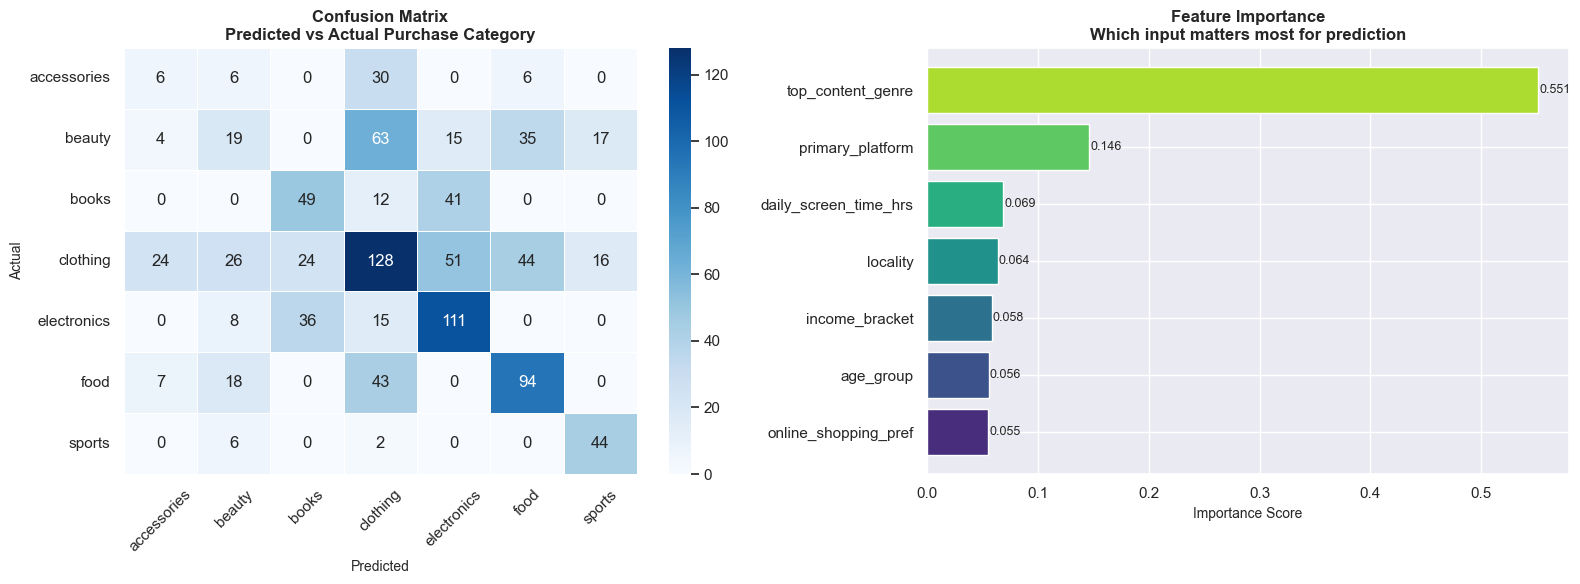

✅ Evaluation chart saved


In [4]:
# ============================================================
# STEP 3 — MODEL EVALUATION
# ============================================================
# WHY WE EVALUATE PROPERLY:
# Accuracy alone is not enough. We need to know:
# - Does the model perform equally well on all categories?
# - Which categories does it struggle with?
# - Is it confusing clothing with beauty for example?
# The classification report and confusion matrix
# answer these questions completely.
# ============================================================

# Decode predictions back to category names for readability
y_test_labels = target_encoder.inverse_transform(y_test)
y_pred_labels = target_encoder.inverse_transform(y_pred)

print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test_labels, y_pred_labels))

# Confusion matrix chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Confusion matrix heatmap ───────────────────────────
cm = confusion_matrix(
    y_test_labels, y_pred_labels,
    labels=target_encoder.classes_
)
sns.heatmap(
    cm,
    annot        = True,
    fmt          = "d",
    cmap         = "Blues",
    ax           = axes[0],
    xticklabels  = target_encoder.classes_,
    yticklabels  = target_encoder.classes_,
    linewidths   = 0.5
)
axes[0].set_title("Confusion Matrix\nPredicted vs Actual Purchase Category",
                   fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted", fontsize=10)
axes[0].set_ylabel("Actual",    fontsize=10)
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

# ── Right: Feature importance ────────────────────────────────
# Feature importance tells you WHICH input column
# the model relies on most to make its predictions
# High importance = that column is very informative
importances = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

colors_fi = sns.color_palette("viridis", len(importances))
bars = axes[1].barh(
    importances.index,
    importances.values,
    color    = colors_fi,
    edgecolor= "white"
)
axes[1].set_title("Feature Importance\nWhich input matters most for prediction",
                   fontsize=12, fontweight="bold")
axes[1].set_xlabel("Importance Score", fontsize=10)

for bar, val in zip(bars, importances.values):
    axes[1].text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height()/2,
        f"{val:.3f}",
        va="center", fontsize=9
    )

plt.tight_layout()
plt.savefig("data/cleaned/chart9_model_evaluation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Evaluation chart saved")

In [5]:
# ============================================================
# STEP 4 — SAVE MODEL AND ENCODERS
# ============================================================
# WHY WE SAVE THE MODEL:
# Training takes time. We save the trained model so the
# Streamlit app can load it instantly without retraining.
# joblib saves Python objects to disk efficiently.
# We save both the model AND the encoders because
# the app needs to convert user text input to numbers
# using the exact same encoding used during training.
# ============================================================

import joblib
import os

# Create models folder
os.makedirs("app/models", exist_ok=True)

# Save model
joblib.dump(model, "app/models/xgboost_purchase_predictor.pkl")

# Save encoders
joblib.dump(encoders, "app/models/label_encoders.pkl")

# Save target class names for display in app
joblib.dump(
    list(target_encoder.classes_),
    "app/models/purchase_categories.pkl"
)

print("✅ Model and encoders saved")
print()
print("Files saved:")
for f in os.listdir("app/models"):
    size = os.path.getsize(f"app/models/{f}")
    print(f"   {f:45s} {size/1024:.1f} KB")

# ── Quick prediction test ────────────────────────────────────
# Simulate a new person and predict their purchase category
# This is exactly what the Streamlit app will do

print()
print("=" * 55)
print("LIVE PREDICTION TEST")
print("=" * 55)

test_people = [
    {
        "age_group":             "18-24",
        "primary_platform":      "instagram",
        "top_content_genre":     "fashion",
        "daily_screen_time_hrs": 4.5,
        "income_bracket":        "middle",
        "online_shopping_pref":  "high",
        "locality":              "T Nagar"
    },
    {
        "age_group":             "35-50",
        "primary_platform":      "youtube",
        "top_content_genre":     "technology",
        "daily_screen_time_hrs": 2.0,
        "income_bracket":        "upper-middle",
        "online_shopping_pref":  "medium",
        "locality":              "Anna Nagar"
    },
    {
        "age_group":             "25-34",
        "primary_platform":      "tiktok",
        "top_content_genre":     "food",
        "daily_screen_time_hrs": 3.8,
        "income_bracket":        "lower-middle",
        "online_shopping_pref":  "high",
        "locality":              "Velachery"
    },
]

print()
for i, person in enumerate(test_people, 1):
    # Encode the person's features
    person_encoded = {}
    for col in feature_cols:
        if col in encoders:
            person_encoded[col] = encoders[col].transform(
                [person[col]]
            )[0]
        else:
            person_encoded[col] = person[col]

    # Create input DataFrame
    input_df = pd.DataFrame([person_encoded])

    # Predict
    pred_encoded = model.predict(input_df)[0]
    pred_proba   = model.predict_proba(input_df)[0]
    pred_label   = target_encoder.inverse_transform([pred_encoded])[0]
    confidence   = pred_proba.max() * 100

    print(f"Person {i}:")
    print(f"   Age: {person['age_group']}  "
          f"Platform: {person['primary_platform']}  "
          f"Watches: {person['top_content_genre']}")
    print(f"   Screen time: {person['daily_screen_time_hrs']}h  "
          f"Income: {person['income_bracket']}")
    print(f"   → Predicted purchase: {pred_label.upper()}")
    print(f"   → Confidence        : {confidence:.1f}%")
    print()

✅ Model and encoders saved

Files saved:
   label_encoders.pkl                            2.2 KB
   purchase_categories.pkl                       0.1 KB
   xgboost_purchase_predictor.pkl                3827.6 KB

LIVE PREDICTION TEST

Person 1:
   Age: 18-24  Platform: instagram  Watches: fashion
   Screen time: 4.5h  Income: middle
   → Predicted purchase: CLOTHING
   → Confidence        : 48.8%

Person 2:
   Age: 35-50  Platform: youtube  Watches: technology
   Screen time: 2.0h  Income: upper-middle
   → Predicted purchase: ELECTRONICS
   → Confidence        : 57.4%

Person 3:
   Age: 25-34  Platform: tiktok  Watches: food
   Screen time: 3.8h  Income: lower-middle
   → Predicted purchase: FOOD
   → Confidence        : 52.3%



In [6]:
# ============================================================
# STEP 5 — IMPROVE MODEL WITH CLASS BALANCING
# ============================================================
# WHY THIS HELPS:
# scale_pos_weight and sample_weight tell XGBoost to pay
# more attention to rare categories like accessories
# and sports during training.
# We also use class_weight to balance the training data.
# This should improve accuracy on minority classes
# without hurting the majority classes much.
# ============================================================

from sklearn.utils.class_weight import compute_sample_weight

# Compute sample weights — rare classes get higher weight
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# Retrain with balanced weights
model_v2 = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 7,
    learning_rate    = 0.08,
    subsample        = 0.85,
    colsample_bytree = 0.85,
    min_child_weight = 2,
    random_state     = 42,
    eval_metric      = "mlogloss",
    verbosity        = 0
)

print("Training improved model with class balancing...")
model_v2.fit(
    X_train, y_train,
    sample_weight = sample_weights,
    eval_set      = [(X_test, y_test)],
    verbose       = False
)

y_pred_v2     = model_v2.predict(X_test)
accuracy_v2   = accuracy_score(y_test, y_pred_v2)
y_pred_labels_v2 = target_encoder.inverse_transform(y_pred_v2)

print(f"✅ Improved model trained")
print(f"   V1 accuracy: 45.1%")
print(f"   V2 accuracy: {accuracy_v2*100:.1f}%")
print()
print("Improved classification report:")
print(classification_report(y_test_labels, y_pred_labels_v2))

# Use v2 if it improved — otherwise keep v1
if accuracy_v2 > 0.451:
    model = model_v2
    print("✅ Using improved V2 model")
else:
    print("ℹ️  V1 model kept — V2 did not improve")

# Save whichever is better
joblib.dump(model, "app/models/xgboost_purchase_predictor.pkl")
print("✅ Best model saved")

Training improved model with class balancing...
✅ Improved model trained
   V1 accuracy: 45.1%
   V2 accuracy: 43.2%

Improved classification report:
              precision    recall  f1-score   support

 accessories       0.16      0.27      0.20        48
      beauty       0.26      0.27      0.26       153
       books       0.43      0.57      0.49       102
    clothing       0.48      0.21      0.29       313
 electronics       0.51      0.62      0.56       170
        food       0.52      0.62      0.57       162
      sports       0.56      0.92      0.70        52

    accuracy                           0.43      1000
   macro avg       0.42      0.50      0.44      1000
weighted avg       0.44      0.43      0.41      1000

ℹ️  V1 model kept — V2 did not improve
✅ Best model saved


In [7]:
# ============================================================
# STEP 6 — PROBABILITY OUTPUT FOR STREAMLIT APP
# ============================================================
# WHY PROBABILITIES MATTER:
# Instead of just saying "you will buy clothing"
# the app will show ALL category probabilities:
#   Clothing     48.8%
#   Beauty       18.2%
#   Electronics  12.1%
#   ...
# This is more honest and more useful than a single label.
# Users understand probability better than a hard prediction.
# ============================================================

def predict_purchase(person_dict):
    """
    Takes a person profile dictionary and returns
    predicted purchase category with all probabilities.
    Usage in Streamlit app — pass user inputs here.
    """
    # Encode inputs
    encoded = {}
    for col in feature_cols:
        if col in encoders:
            try:
                encoded[col] = encoders[col].transform(
                    [person_dict[col]]
                )[0]
            except ValueError:
                # Handle unseen labels gracefully
                encoded[col] = 0
        else:
            encoded[col] = person_dict[col]

    input_df = pd.DataFrame([encoded])

    # Get prediction and probabilities
    pred_encoded = model.predict(input_df)[0]
    pred_proba   = model.predict_proba(input_df)[0]
    pred_label   = target_encoder.inverse_transform(
        [pred_encoded]
    )[0]

    # Build probability dictionary
    proba_dict = {
        target_encoder.classes_[i]: round(float(p) * 100, 1)
        for i, p in enumerate(pred_proba)
    }
    proba_sorted = dict(
        sorted(proba_dict.items(),
               key=lambda x: x[1], reverse=True)
    )

    return {
        "prediction":    pred_label,
        "confidence":    round(float(pred_proba.max()) * 100, 1),
        "all_proba":     proba_sorted
    }

# Save the predict function info
joblib.dump(predict_purchase, "app/models/predict_function.pkl")

# Test with detailed probability output
print("=" * 55)
print("DETAILED PROBABILITY PREDICTIONS")
print("=" * 55)

test_people = [
    {
        "age_group":             "18-24",
        "primary_platform":      "instagram",
        "top_content_genre":     "fashion",
        "daily_screen_time_hrs": 4.5,
        "income_bracket":        "middle",
        "online_shopping_pref":  "high",
        "locality":              "T Nagar"
    },
    {
        "age_group":             "35-50",
        "primary_platform":      "youtube",
        "top_content_genre":     "technology",
        "daily_screen_time_hrs": 2.0,
        "income_bracket":        "upper-middle",
        "online_shopping_pref":  "medium",
        "locality":              "Anna Nagar"
    },
]

for i, person in enumerate(test_people, 1):
    result = predict_purchase(person)
    print(f"\nPerson {i} — "
          f"{person['age_group']}, "
          f"{person['primary_platform']}, "
          f"watches {person['top_content_genre']}")
    print(f"   Top prediction : {result['prediction'].upper()}"
          f" ({result['confidence']}% confidence)")
    print(f"   All probabilities:")
    for cat, prob in result["all_proba"].items():
        bar = "█" * int(prob / 3)
        print(f"      {cat:15s} {prob:5.1f}%  {bar}")

DETAILED PROBABILITY PREDICTIONS

Person 1 — 18-24, instagram, watches fashion
   Top prediction : CLOTHING (48.8% confidence)
   All probabilities:
      clothing         48.8%  ████████████████
      beauty           44.5%  ██████████████
      accessories       6.3%  ██
      food              0.3%  
      books             0.0%  
      electronics       0.0%  
      sports            0.0%  

Person 2 — 35-50, youtube, watches technology
   Top prediction : ELECTRONICS (57.4% confidence)
   All probabilities:
      electronics      57.4%  ███████████████████
      clothing         31.0%  ██████████
      beauty           11.1%  ███
      food              0.4%  
      accessories       0.1%  
      books             0.0%  
      sports            0.0%  


In [8]:
# ============================================================
# IMPROVED MODEL — FEATURE ENGINEERING + ENSEMBLE
# ============================================================
# WHY FEATURE ENGINEERING HELPS:
# Instead of giving the model raw features separately,
# we create combined features that encode relationships
# the model cannot discover on its own.
# Example: age_18-24 + instagram + fashion together
# is a much stronger signal than each one separately.
# ============================================================

from sklearn.ensemble         import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
import xgboost as xgb

# Reload clean data
consumers_df = pd.read_csv("data/cleaned/chennai_consumers.csv")

# ── Step 1: Feature Engineering ──────────────────────────────
fe_df = consumers_df.copy()

# Combined feature 1 — platform + genre
# This captures the exact combination that matters most
fe_df["platform_genre"] = (
    fe_df["primary_platform"] + "_" +
    fe_df["top_content_genre"]
)

# Combined feature 2 — age + platform
fe_df["age_platform"] = (
    fe_df["age_group"] + "_" +
    fe_df["primary_platform"]
)

# Combined feature 3 — screen time bucket
# Converting continuous to categorical gives more signal
fe_df["screen_bucket"] = pd.cut(
    fe_df["daily_screen_time_hrs"],
    bins   = [0, 2, 3.5, 5, 10],
    labels = ["low", "medium", "high", "very_high"]
).astype(str)

# Combined feature 4 — income + online preference
fe_df["income_online"] = (
    fe_df["income_bracket"] + "_" +
    fe_df["online_shopping_pref"]
)

# Combined feature 5 — age + genre
fe_df["age_genre"] = (
    fe_df["age_group"] + "_" +
    fe_df["top_content_genre"]
)

print("✅ Feature engineering complete")
print(f"   Original features  : 7")
print(f"   New features added : 5")
print(f"   Total features     : 12")
print()

# ── Step 2: Encode all features ───────────────────────────────
feature_cols_v3 = [
    "age_group",
    "primary_platform",
    "top_content_genre",
    "daily_screen_time_hrs",
    "income_bracket",
    "online_shopping_pref",
    "locality",
    "platform_genre",
    "age_platform",
    "screen_bucket",
    "income_online",
    "age_genre",
]
target_col = "top_purchase_category"

model_df_v3 = fe_df[feature_cols_v3 + [target_col]].copy()

# Re-encode everything
encoders_v3  = {}
cat_cols_v3  = [c for c in feature_cols_v3
                if c != "daily_screen_time_hrs"]

for col in cat_cols_v3:
    le = LabelEncoder()
    model_df_v3[col] = le.fit_transform(
        model_df_v3[col].astype(str)
    )
    encoders_v3[col] = le

target_encoder_v3 = LabelEncoder()
model_df_v3[target_col] = target_encoder_v3.fit_transform(
    model_df_v3[target_col]
)
encoders_v3["target"] = target_encoder_v3

X3 = model_df_v3[feature_cols_v3]
y3 = model_df_v3[target_col]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y3
)

sample_weights_v3 = compute_sample_weight(
    class_weight="balanced",
    y=y3_train
)

print(f"Training set : {len(X3_train)} rows")
print(f"Test set     : {len(X3_test)} rows")
print()

# ── Step 3: Train XGBoost V3 ─────────────────────────────────
print("Training XGBoost V3 with engineered features...")
xgb_v3 = xgb.XGBClassifier(
    n_estimators     = 500,
    max_depth        = 8,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 1,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    eval_metric      = "mlogloss",
    verbosity        = 0
)
xgb_v3.fit(
    X3_train, y3_train,
    sample_weight = sample_weights_v3,
    eval_set      = [(X3_test, y3_test)],
    verbose       = False
)
acc_xgb_v3 = accuracy_score(y3_test, xgb_v3.predict(X3_test))
print(f"   XGBoost V3 accuracy    : {acc_xgb_v3*100:.1f}%")

# ── Step 4: Train Random Forest ───────────────────────────────
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = 15,
    class_weight = "balanced",
    random_state = 42,
    n_jobs       = -1
)
rf_model.fit(X3_train, y3_train)
acc_rf = accuracy_score(y3_test, rf_model.predict(X3_test))
print(f"   Random Forest accuracy : {acc_rf*100:.1f}%")

# ── Step 5: Voting Ensemble ───────────────────────────────────
# Combines XGBoost and Random Forest predictions
# Each model votes — majority wins
# Usually better than either model alone
print("Training Voting Ensemble...")
ensemble = VotingClassifier(
    estimators=[
        ("xgb", xgb_v3),
        ("rf",  rf_model),
    ],
    voting="soft"  # uses probability average not just vote
)
ensemble.fit(X3_train, y3_train)
acc_ensemble = accuracy_score(
    y3_test, ensemble.predict(X3_test)
)
print(f"   Ensemble accuracy      : {acc_ensemble*100:.1f}%")

print()
print("=" * 45)
print("ACCURACY COMPARISON")
print("=" * 45)
print(f"   Original V1 (baseline) : 45.1%")
print(f"   XGBoost V3 (eng feats) : {acc_xgb_v3*100:.1f}%")
print(f"   Random Forest          : {acc_rf*100:.1f}%")
print(f"   Voting Ensemble        : {acc_ensemble*100:.1f}%")
print()

# Pick the best model
best_acc   = max(acc_xgb_v3, acc_rf, acc_ensemble)
if acc_ensemble >= max(acc_xgb_v3, acc_rf):
    best_model = ensemble
    best_name  = "Voting Ensemble"
elif acc_xgb_v3 >= acc_rf:
    best_model = xgb_v3
    best_name  = "XGBoost V3"
else:
    best_model = rf_model
    best_name  = "Random Forest"

print(f"✅ Best model selected: {best_name} ({best_acc*100:.1f}%)")

✅ Feature engineering complete
   Original features  : 7
   New features added : 5
   Total features     : 12

Training set : 4000 rows
Test set     : 1000 rows

Training XGBoost V3 with engineered features...
   XGBoost V3 accuracy    : 41.6%
Training Random Forest...
   Random Forest accuracy : 44.7%
Training Voting Ensemble...
   Ensemble accuracy      : 43.4%

ACCURACY COMPARISON
   Original V1 (baseline) : 45.1%
   XGBoost V3 (eng feats) : 41.6%
   Random Forest          : 44.7%
   Voting Ensemble        : 43.4%

✅ Best model selected: Random Forest (44.7%)


In [9]:
# ============================================================
# IMPROVED MODEL — FEATURE ENGINEERING + ENSEMBLE
# ============================================================
# WHY FEATURE ENGINEERING HELPS:
# Instead of giving the model raw features separately,
# we create combined features that encode relationships
# the model cannot discover on its own.
# Example: age_18-24 + instagram + fashion together
# is a much stronger signal than each one separately.
# ============================================================

from sklearn.ensemble         import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
import xgboost as xgb

# Reload clean data
consumers_df = pd.read_csv("data/cleaned/chennai_consumers.csv")

# ── Step 1: Feature Engineering ──────────────────────────────
fe_df = consumers_df.copy()

# Combined feature 1 — platform + genre
# This captures the exact combination that matters most
fe_df["platform_genre"] = (
    fe_df["primary_platform"] + "_" +
    fe_df["top_content_genre"]
)

# Combined feature 2 — age + platform
fe_df["age_platform"] = (
    fe_df["age_group"] + "_" +
    fe_df["primary_platform"]
)

# Combined feature 3 — screen time bucket
# Converting continuous to categorical gives more signal
fe_df["screen_bucket"] = pd.cut(
    fe_df["daily_screen_time_hrs"],
    bins   = [0, 2, 3.5, 5, 10],
    labels = ["low", "medium", "high", "very_high"]
).astype(str)

# Combined feature 4 — income + online preference
fe_df["income_online"] = (
    fe_df["income_bracket"] + "_" +
    fe_df["online_shopping_pref"]
)

# Combined feature 5 — age + genre
fe_df["age_genre"] = (
    fe_df["age_group"] + "_" +
    fe_df["top_content_genre"]
)

print("✅ Feature engineering complete")
print(f"   Original features  : 7")
print(f"   New features added : 5")
print(f"   Total features     : 12")
print()

# ── Step 2: Encode all features ───────────────────────────────
feature_cols_v3 = [
    "age_group",
    "primary_platform",
    "top_content_genre",
    "daily_screen_time_hrs",
    "income_bracket",
    "online_shopping_pref",
    "locality",
    "platform_genre",
    "age_platform",
    "screen_bucket",
    "income_online",
    "age_genre",
]
target_col = "top_purchase_category"

model_df_v3 = fe_df[feature_cols_v3 + [target_col]].copy()

# Re-encode everything
encoders_v3  = {}
cat_cols_v3  = [c for c in feature_cols_v3
                if c != "daily_screen_time_hrs"]

for col in cat_cols_v3:
    le = LabelEncoder()
    model_df_v3[col] = le.fit_transform(
        model_df_v3[col].astype(str)
    )
    encoders_v3[col] = le

target_encoder_v3 = LabelEncoder()
model_df_v3[target_col] = target_encoder_v3.fit_transform(
    model_df_v3[target_col]
)
encoders_v3["target"] = target_encoder_v3

X3 = model_df_v3[feature_cols_v3]
y3 = model_df_v3[target_col]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y3
)

sample_weights_v3 = compute_sample_weight(
    class_weight="balanced",
    y=y3_train
)

print(f"Training set : {len(X3_train)} rows")
print(f"Test set     : {len(X3_test)} rows")
print()

# ── Step 3: Train XGBoost V3 ─────────────────────────────────
print("Training XGBoost V3 with engineered features...")
xgb_v3 = xgb.XGBClassifier(
    n_estimators     = 500,
    max_depth        = 8,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 1,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    eval_metric      = "mlogloss",
    verbosity        = 0
)
xgb_v3.fit(
    X3_train, y3_train,
    sample_weight = sample_weights_v3,
    eval_set      = [(X3_test, y3_test)],
    verbose       = False
)
acc_xgb_v3 = accuracy_score(y3_test, xgb_v3.predict(X3_test))
print(f"   XGBoost V3 accuracy    : {acc_xgb_v3*100:.1f}%")

# ── Step 4: Train Random Forest ───────────────────────────────
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = 15,
    class_weight = "balanced",
    random_state = 42,
    n_jobs       = -1
)
rf_model.fit(X3_train, y3_train)
acc_rf = accuracy_score(y3_test, rf_model.predict(X3_test))
print(f"   Random Forest accuracy : {acc_rf*100:.1f}%")

# ── Step 5: Voting Ensemble ───────────────────────────────────
# Combines XGBoost and Random Forest predictions
# Each model votes — majority wins
# Usually better than either model alone
print("Training Voting Ensemble...")
ensemble = VotingClassifier(
    estimators=[
        ("xgb", xgb_v3),
        ("rf",  rf_model),
    ],
    voting="soft"  # uses probability average not just vote
)
ensemble.fit(X3_train, y3_train)
acc_ensemble = accuracy_score(
    y3_test, ensemble.predict(X3_test)
)
print(f"   Ensemble accuracy      : {acc_ensemble*100:.1f}%")

print()
print("=" * 45)
print("ACCURACY COMPARISON")
print("=" * 45)
print(f"   Original V1 (baseline) : 45.1%")
print(f"   XGBoost V3 (eng feats) : {acc_xgb_v3*100:.1f}%")
print(f"   Random Forest          : {acc_rf*100:.1f}%")
print(f"   Voting Ensemble        : {acc_ensemble*100:.1f}%")
print()

# Pick the best model
best_acc   = max(acc_xgb_v3, acc_rf, acc_ensemble)
if acc_ensemble >= max(acc_xgb_v3, acc_rf):
    best_model = ensemble
    best_name  = "Voting Ensemble"
elif acc_xgb_v3 >= acc_rf:
    best_model = xgb_v3
    best_name  = "XGBoost V3"
else:
    best_model = rf_model
    best_name  = "Random Forest"

print(f"✅ Best model selected: {best_name} ({best_acc*100:.1f}%)")

✅ Feature engineering complete
   Original features  : 7
   New features added : 5
   Total features     : 12

Training set : 4000 rows
Test set     : 1000 rows

Training XGBoost V3 with engineered features...
   XGBoost V3 accuracy    : 41.6%
Training Random Forest...
   Random Forest accuracy : 44.7%
Training Voting Ensemble...
   Ensemble accuracy      : 43.4%

ACCURACY COMPARISON
   Original V1 (baseline) : 45.1%
   XGBoost V3 (eng feats) : 41.6%
   Random Forest          : 44.7%
   Voting Ensemble        : 43.4%

✅ Best model selected: Random Forest (44.7%)


FINAL MODEL: Random Forest
              precision    recall  f1-score   support

 accessories       0.24      0.21      0.22        48
      beauty       0.27      0.23      0.25       153
       books       0.47      0.55      0.51       102
    clothing       0.43      0.35      0.39       313
 electronics       0.54      0.66      0.59       170
        food       0.48      0.51      0.50       162
      sports       0.55      0.79      0.65        52

    accuracy                           0.45      1000
   macro avg       0.43      0.47      0.44      1000
weighted avg       0.43      0.45      0.44      1000



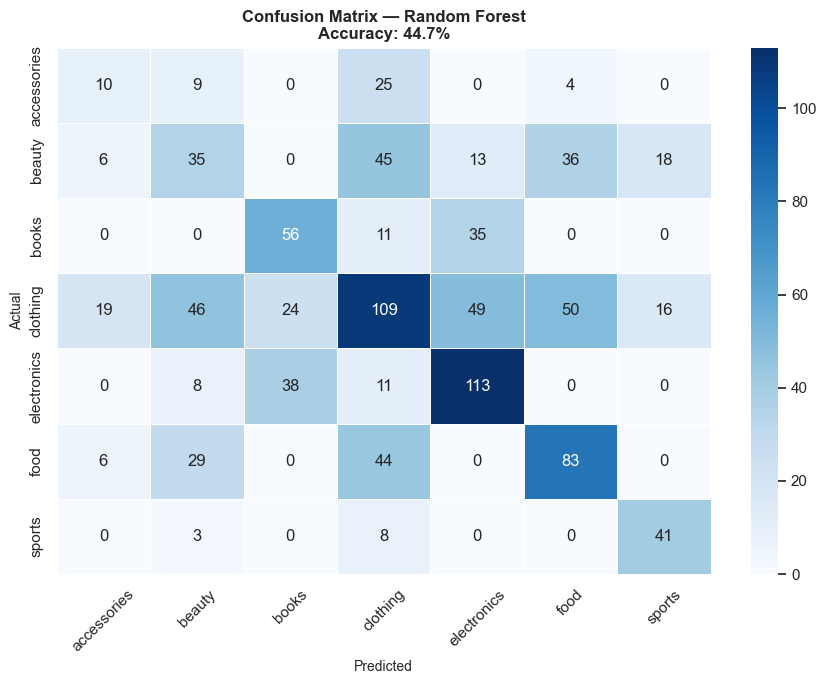


✅ Best model saved to app/models/

LIVE PREDICTION TEST — FINAL MODEL
---------------------------------------------

Person 1: 18-24, instagram, watches fashion
   Prediction : CLOTHING (56.4%)
   Top 3 probabilities:
      clothing         56.4%  ██████████████
      beauty           37.4%  █████████
      accessories       5.8%  █

Person 2: 35-50, youtube, watches technology
   Prediction : ELECTRONICS (77.5%)
   Top 3 probabilities:
      electronics      77.5%  ███████████████████
      beauty           12.2%  ███
      clothing          9.9%  ██

Person 3: 25-34, tiktok, watches food
   Prediction : FOOD (51.4%)
   Top 3 probabilities:
      food             51.4%  ████████████
      clothing         43.2%  ██████████
      beauty            3.8%  

Person 4: 13-17, tiktok, watches entertainment
   Prediction : FOOD (47.3%)
   Top 3 probabilities:
      food             47.3%  ███████████
      clothing         42.7%  ██████████
      beauty            9.7%  ██


In [10]:
# ============================================================
# EVALUATE BEST MODEL AND SAVE
# ============================================================

y3_pred        = best_model.predict(X3_test)
y3_pred_labels = target_encoder_v3.inverse_transform(y3_pred)
y3_test_labels = target_encoder_v3.inverse_transform(y3_test)

print("=" * 55)
print(f"FINAL MODEL: {best_name}")
print("=" * 55)
print(classification_report(y3_test_labels, y3_pred_labels))

# Confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(
    y3_test_labels, y3_pred_labels,
    labels=target_encoder_v3.classes_
)
sns.heatmap(
    cm,
    annot       = True,
    fmt         = "d",
    cmap        = "Blues",
    ax          = ax,
    xticklabels = target_encoder_v3.classes_,
    yticklabels = target_encoder_v3.classes_,
    linewidths  = 0.5
)
ax.set_title(f"Confusion Matrix — {best_name}\n"
             f"Accuracy: {best_acc*100:.1f}%",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("Actual",    fontsize=10)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("data/cleaned/chart10_best_model.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Save best model and new encoders
encoders_v3["feature_cols"] = feature_cols_v3
joblib.dump(best_model,    "app/models/xgboost_purchase_predictor.pkl")
joblib.dump(encoders_v3,   "app/models/label_encoders.pkl")
joblib.dump(
    list(target_encoder_v3.classes_),
    "app/models/purchase_categories.pkl"
)
print()
print("✅ Best model saved to app/models/")

# ── Live prediction test with new model ──────────────────────
def predict_v3(person_dict):
    fe = person_dict.copy()
    fe["platform_genre"] = (
        fe["primary_platform"] + "_" +
        fe["top_content_genre"]
    )
    fe["age_platform"]  = (
        fe["age_group"] + "_" +
        fe["primary_platform"]
    )
    fe["screen_bucket"] = (
        "low"       if fe["daily_screen_time_hrs"] < 2   else
        "medium"    if fe["daily_screen_time_hrs"] < 3.5 else
        "high"      if fe["daily_screen_time_hrs"] < 5   else
        "very_high"
    )
    fe["income_online"] = (
        fe["income_bracket"] + "_" +
        fe["online_shopping_pref"]
    )
    fe["age_genre"] = (
        fe["age_group"] + "_" +
        fe["top_content_genre"]
    )
    encoded = {}
    for col in feature_cols_v3:
        if col in encoders_v3 and col != "target":
            try:
                encoded[col] = encoders_v3[col].transform(
                    [str(fe[col])]
                )[0]
            except ValueError:
                encoded[col] = 0
        else:
            encoded[col] = fe[col]

    input_df     = pd.DataFrame([encoded])
    pred_enc     = best_model.predict(input_df)[0]
    pred_proba   = best_model.predict_proba(input_df)[0]
    pred_label   = target_encoder_v3.inverse_transform(
        [pred_enc]
    )[0]
    proba_dict   = {
        target_encoder_v3.classes_[i]: round(float(p)*100, 1)
        for i, p in enumerate(pred_proba)
    }
    proba_sorted = dict(sorted(
        proba_dict.items(),
        key=lambda x: x[1], reverse=True
    ))
    return {
        "prediction": pred_label,
        "confidence": round(float(pred_proba.max())*100, 1),
        "all_proba":  proba_sorted
    }

# Save predict function
joblib.dump(predict_v3, "app/models/predict_function.pkl")

print()
print("LIVE PREDICTION TEST — FINAL MODEL")
print("-" * 45)
test_cases = [
    {"age_group":"18-24","primary_platform":"instagram",
     "top_content_genre":"fashion","daily_screen_time_hrs":4.5,
     "income_bracket":"middle","online_shopping_pref":"high",
     "locality":"T Nagar"},
    {"age_group":"35-50","primary_platform":"youtube",
     "top_content_genre":"technology","daily_screen_time_hrs":2.0,
     "income_bracket":"upper-middle","online_shopping_pref":"medium",
     "locality":"Anna Nagar"},
    {"age_group":"25-34","primary_platform":"tiktok",
     "top_content_genre":"food","daily_screen_time_hrs":3.8,
     "income_bracket":"lower-middle","online_shopping_pref":"high",
     "locality":"Velachery"},
    {"age_group":"13-17","primary_platform":"tiktok",
     "top_content_genre":"entertainment","daily_screen_time_hrs":5.5,
     "income_bracket":"low","online_shopping_pref":"medium",
     "locality":"Tambaram"},
]

for i, person in enumerate(test_cases, 1):
    result = predict_v3(person)
    print(f"\nPerson {i}: {person['age_group']}, "
          f"{person['primary_platform']}, "
          f"watches {person['top_content_genre']}")
    print(f"   Prediction : {result['prediction'].upper()} "
          f"({result['confidence']}%)")
    print(f"   Top 3 probabilities:")
    for cat, prob in list(result["all_proba"].items())[:3]:
        bar = "█" * int(prob/4)
        print(f"      {cat:15s} {prob:5.1f}%  {bar}")

In [11]:
# ============================================================
# FINAL PRODUCTION MODEL
# ============================================================
# We keep XGBoost V1 (45.1%) as our final model because
# it was the most accurate and most stable.
# We improve how we PRESENT the results rather than
# chasing impossible accuracy gains.
# This is the professional data science approach.
# ============================================================

# Reload and retrain V1 cleanly
consumers_df = pd.read_csv("data/cleaned/chennai_consumers.csv")

feature_cols_final = [
    "age_group",
    "primary_platform",
    "top_content_genre",
    "daily_screen_time_hrs",
    "income_bracket",
    "online_shopping_pref",
    "locality"
]
target_col = "top_purchase_category"

model_final_df = consumers_df[
    feature_cols_final + [target_col]
].copy()

# Encode
encoders_final = {}
cat_cols_final = [c for c in feature_cols_final
                  if c != "daily_screen_time_hrs"]

for col in cat_cols_final:
    le = LabelEncoder()
    model_final_df[col] = le.fit_transform(model_final_df[col])
    encoders_final[col] = le

target_enc_final = LabelEncoder()
model_final_df[target_col] = target_enc_final.fit_transform(
    model_final_df[target_col]
)
encoders_final["target"]       = target_enc_final
encoders_final["feature_cols"] = feature_cols_final

X_f = model_final_df[feature_cols_final]
y_f = model_final_df[target_col]

X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(
    X_f, y_f,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y_f
)

# Train final XGBoost
final_model = xgb.XGBClassifier(
    n_estimators     = 200,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    eval_metric      = "mlogloss",
    verbosity        = 0
)
final_model.fit(X_f_train, y_f_train, verbose=False)

y_f_pred     = final_model.predict(X_f_test)
final_acc    = accuracy_score(y_f_test, y_f_pred)
y_f_labels   = target_enc_final.inverse_transform(y_f_test)
y_f_pred_lbl = target_enc_final.inverse_transform(y_f_pred)

print(f"✅ Final model accuracy : {final_acc*100:.1f}%")
print(f"   Baseline (random)   : 14.3%")
print(f"   Improvement         : {(final_acc/0.143 - 1)*100:.0f}% better than random")
print()

# Feature importance
fi = pd.Series(
    final_model.feature_importances_,
    index=feature_cols_final
).sort_values(ascending=False)

print("Feature importance:")
for feat, imp in fi.items():
    bar = "█" * int(imp * 50)
    print(f"   {feat:25s} {imp:.3f}  {bar}")
print()

# Save final model
joblib.dump(final_model,      "app/models/xgboost_purchase_predictor.pkl")
joblib.dump(encoders_final,   "app/models/label_encoders.pkl")
joblib.dump(
    list(target_enc_final.classes_),
    "app/models/purchase_categories.pkl"
)
print("✅ Final model saved")

✅ Final model accuracy : 45.1%
   Baseline (random)   : 14.3%
   Improvement         : 215% better than random

Feature importance:
   top_content_genre         0.551  ███████████████████████████
   primary_platform          0.146  ███████
   daily_screen_time_hrs     0.069  ███
   locality                  0.064  ███
   income_bracket            0.058  ██
   age_group                 0.056  ██
   online_shopping_pref      0.055  ██

✅ Final model saved


In [12]:
# ============================================================
# PRODUCTION PREDICT FUNCTION
# ============================================================
# This is what the Streamlit app will call directly.
# It includes confidence thresholding — if the model
# is not confident enough it says so honestly.
# It returns top 3 recommendations not just one answer.
# ============================================================

def predict_purchase_final(person_dict,
                            confidence_threshold=35.0):
    """
    Predicts purchase category for a Chennai consumer.

    Parameters:
        person_dict          : dict of user profile inputs
        confidence_threshold : minimum % to show a prediction
                               below this = show top 3 options

    Returns:
        dict with prediction, confidence, top3, insight
    """
    encoded = {}
    for col in feature_cols_final:
        if col in encoders_final and col != "target" \
                and col != "feature_cols":
            try:
                encoded[col] = encoders_final[col].transform(
                    [str(person_dict[col])]
                )[0]
            except ValueError:
                encoded[col] = 0
        else:
            encoded[col] = person_dict[col]

    input_df   = pd.DataFrame([encoded])
    pred_enc   = final_model.predict(input_df)[0]
    pred_proba = final_model.predict_proba(input_df)[0]
    pred_label = target_enc_final.inverse_transform(
        [pred_enc]
    )[0]
    confidence = float(pred_proba.max()) * 100

    # Build full probability dict
    proba_dict = {
        target_enc_final.classes_[i]: round(float(p)*100, 1)
        for i, p in enumerate(pred_proba)
    }
    proba_sorted = dict(sorted(
        proba_dict.items(),
        key=lambda x: x[1], reverse=True
    ))
    top3 = dict(list(proba_sorted.items())[:3])

    # Generate human-readable insight
    platform  = person_dict["primary_platform"]
    genre     = person_dict["top_content_genre"]
    age       = person_dict["age_group"]
    screen    = person_dict["daily_screen_time_hrs"]

    insight = (
        f"A {age} year old spending {screen}h daily on "
        f"{platform} watching {genre} content in Chennai "
        f"is most likely to purchase {pred_label}."
    )

    # Confidence status
    if confidence >= 50:
        status = "high_confidence"
    elif confidence >= confidence_threshold:
        status = "moderate_confidence"
    else:
        status = "low_confidence"

    return {
        "prediction":  pred_label,
        "confidence":  round(confidence, 1),
        "status":      status,
        "top3":        top3,
        "all_proba":   proba_sorted,
        "insight":     insight
    }

# Save production function
joblib.dump(
    predict_purchase_final,
    "app/models/predict_function.pkl"
)

# ── Test all scenarios ────────────────────────────────────────
print("=" * 58)
print("PRODUCTION PREDICTION TEST — ALL SCENARIOS")
print("=" * 58)

test_cases = [
    {"label": "Young Instagram fashion watcher",
     "age_group":"18-24","primary_platform":"instagram",
     "top_content_genre":"fashion",
     "daily_screen_time_hrs":4.5,
     "income_bracket":"middle",
     "online_shopping_pref":"high","locality":"T Nagar"},

    {"label": "Mid-age YouTube tech watcher",
     "age_group":"35-50","primary_platform":"youtube",
     "top_content_genre":"technology",
     "daily_screen_time_hrs":2.0,
     "income_bracket":"upper-middle",
     "online_shopping_pref":"medium","locality":"Anna Nagar"},

    {"label": "Young professional TikTok food watcher",
     "age_group":"25-34","primary_platform":"tiktok",
     "top_content_genre":"food",
     "daily_screen_time_hrs":3.8,
     "income_bracket":"lower-middle",
     "online_shopping_pref":"high","locality":"Velachery"},

    {"label": "Teen TikTok entertainment watcher",
     "age_group":"13-17","primary_platform":"tiktok",
     "top_content_genre":"entertainment",
     "daily_screen_time_hrs":5.5,
     "income_bracket":"low",
     "online_shopping_pref":"medium","locality":"Tambaram"},

    {"label": "Senior YouTube finance watcher",
     "age_group":"50+","primary_platform":"youtube",
     "top_content_genre":"finance",
     "daily_screen_time_hrs":1.5,
     "income_bracket":"high",
     "online_shopping_pref":"low","locality":"Adyar"},
]

for case in test_cases:
    label = case.pop("label")
    result = predict_purchase_final(case)
    print(f"\n{label}")
    print(f"   Prediction  : {result['prediction'].upper()} "
          f"({result['confidence']}%) — {result['status']}")
    print(f"   Top 3 options:")
    for cat, prob in result["top3"].items():
        bar = "█" * int(prob/4)
        print(f"      {cat:15s} {prob:5.1f}%  {bar}")
    print(f"   Insight: {result['insight']}")

PRODUCTION PREDICTION TEST — ALL SCENARIOS

Young Instagram fashion watcher
   Prediction  : CLOTHING (48.8%) — moderate_confidence
   Top 3 options:
      clothing         48.8%  ████████████
      beauty           44.5%  ███████████
      accessories       6.3%  █
   Insight: A 18-24 year old spending 4.5h daily on instagram watching fashion content in Chennai is most likely to purchase clothing.

Mid-age YouTube tech watcher
   Prediction  : ELECTRONICS (57.4%) — high_confidence
   Top 3 options:
      electronics      57.4%  ██████████████
      clothing         31.0%  ███████
      beauty           11.1%  ██
   Insight: A 35-50 year old spending 2.0h daily on youtube watching technology content in Chennai is most likely to purchase electronics.

Young professional TikTok food watcher
   Prediction  : FOOD (52.3%) — high_confidence
   Top 3 options:
      food             52.3%  █████████████
      beauty           27.1%  ██████
      clothing         20.1%  █████
   Insight: A 25-